# ***GRADIENT BOOSTING: ADABOOST Y XGBOOST***

En este notebook se aplican modelos de **Gradient Boosting** sobre el dataset preprocesado de diabetes.

El análisis se centra principalmente en **AdaBoost** y **XGBoost**, utilizando una metodología equivalente a la aplicada en los otros modelos del proyecto:

- Separación **train/test**.
- Validación cruzada con **5 folds**.
- Búsqueda de hiperparámetros con **GridSearchCV**.
- `param_grid` amplio con **4 hiperparámetros × 4 valores = 256 combinaciones** por modelo principal.
- Selección del mejor modelo mediante **F1 macro**.
- Evaluación final con las métricas solicitadas: **Accuracy**, **Precision**, **Recall** y **F1 Score**.

In [2]:
# Instalación/verificación de librerías necesarias
# Esta celda instala automáticamente los paquetes si no están disponibles en el entorno.

import sys
import subprocess
import importlib.util

paquetes = {
    "pandas": "pandas",
    "numpy": "numpy",
    "scikit-learn": "sklearn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "xgboost": "xgboost"
}

for paquete, modulo in paquetes.items():
    if importlib.util.find_spec(modulo) is None:
        print(f"Instalando {paquete}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", paquete])

print("Librerías verificadas e instaladas correctamente.")

Librerías verificadas e instaladas correctamente.


In [3]:
# Librerías generales
from pathlib import Path
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Separación de datos, validación cruzada y búsqueda de hiperparámetros
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score

# Modelos de boosting
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Métricas solicitadas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.base import clone

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [4]:
# Carga del dataset preprocesado
# Se prueban varias rutas para que el notebook funcione tanto en local como en la estructura del proyecto.

ruta_dataset = "../data/diabetes_preprocesado.csv"

if ruta_dataset is None:
    raise FileNotFoundError("No se ha encontrado el archivo diabetes_preprocesado.csv. Revisa la ruta del dataset.")

df = pd.read_csv(ruta_dataset)

print(f"Dataset cargado desde: {ruta_dataset}")
print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas")

df.head()

Dataset cargado desde: ../data/diabetes_preprocesado.csv
Dimensiones del dataset: 98053 filas y 46 columnas


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,149190,55629189,0.765698,1,1,1,1,7,-0.302638,0.492774,...,0,3,0,0,0,0,0,1,1,1
1,64410,86047875,0.192559,1,2,1,1,7,-0.841183,0.492774,...,0,0,0,0,0,0,0,0,1,0
2,500364,82442376,0.765698,0,3,1,1,7,-0.841183,0.492774,...,0,3,0,0,0,0,0,1,1,0
3,16680,42519267,0.765698,0,4,1,1,7,-1.600220,0.492774,...,0,2,0,0,0,0,0,1,1,0
4,35754,82637451,0.765698,0,5,2,1,2,-0.302638,0.492774,...,0,2,0,0,0,0,0,0,1,1


### 1- Separación Train-Test

Se separan las variables predictoras de la variable objetivo `readmitted` y se divide el dataset en entrenamiento y prueba.

Se utiliza `stratify=y` para mantener una proporción similar de clases en ambos conjuntos.

In [5]:
# 1. Definición de variables predictoras y variable objetivo
X = df.drop("readmitted", axis=1)
y = df["readmitted"]

# 2. División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# 3. Visualización de la distribución de clases
resumen_split = pd.DataFrame({
    "Conjunto": ["Train", "Test"],
    "Filas": [X_train.shape[0], X_test.shape[0]],
    "Columnas predictoras": [X_train.shape[1], X_test.shape[1]]
})

distribucion_clases = pd.concat([
    y_train.value_counts(normalize=True).sort_index().rename("Train"),
    y_test.value_counts(normalize=True).sort_index().rename("Test")
], axis=1).round(4)

distribucion_clases.index.name = "Clase readmitted"

display(resumen_split)
display(distribucion_clases)

,Conjunto,Filas,Columnas predictoras
0,Train,78442,45
1,Test,19611,45


,Train,Test
Clase readmitted,,
0,0.5338,0.5338
1,0.3534,0.3534
2,0.1129,0.1128


In [6]:
# Funciones auxiliares para mantener el mismo formato de tablas en todo el notebook

cv_5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


def metricas_test(modelo, X_test, y_test):
    # Calcula las métricas solicitadas sobre el conjunto de test.
    y_pred = modelo.predict(X_test)
    return {
        "Test Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision Macro": round(precision_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "Recall Macro": round(recall_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "F1-Score Macro": round(f1_score(y_test, y_pred, average="macro", zero_division=0), 4)
    }


def evaluar_modelo_base(nombre, modelo, X_train, X_test, y_train, y_test):
    # Entrena el modelo, calcula validación cruzada con F1 macro y evalúa en test.
    inicio = time.time()
    cv_scores = cross_val_score(
        modelo,
        X_train,
        y_train,
        cv=cv_5,
        scoring="f1_macro",
        n_jobs=-1
    )

    modelo.fit(X_train, y_train)
    metricas = metricas_test(modelo, X_test, y_test)
    tiempo = round(time.time() - inicio, 2)

    fila = {
        "Modelo": nombre,
        "CV F1 Macro": round(cv_scores.mean(), 4),
        "CV Std": round(cv_scores.std(), 4),
        **metricas,
        "Tiempo (s)": tiempo
    }

    return pd.DataFrame([fila]).set_index("Modelo")


def resumen_busqueda_grid(nombre_modelo, grid, param_cols, X_train, X_test, y_train, y_test, top_n=10):
    # Convierte los resultados de GridSearchCV en una tabla con el top de configuraciones.
    cv_results = pd.DataFrame(grid.cv_results_)

    columnas_cv = [f"param_{col}" for col in param_cols]
    resultados = cv_results[
        columnas_cv + ["mean_test_score", "std_test_score", "rank_test_score", "params"]
    ].copy()

    resultados = resultados.rename(columns={
        **{f"param_{col}": col for col in param_cols},
        "mean_test_score": "CV F1 Macro",
        "std_test_score": "CV Std",
        "rank_test_score": "Ranking",
        "params": "__params__"
    })

    resultados = resultados.sort_values(
        by=["Ranking", "CV F1 Macro"],
        ascending=[True, False]
    ).reset_index(drop=True)

    top_resultados = resultados.head(top_n).copy()
    parametros_top = top_resultados["__params__"].tolist()

    metricas_top = []
    for params in parametros_top:
        # Se usan los parámetros originales de GridSearchCV para conservar tipos correctos.
        modelo_tmp = clone(grid.estimator).set_params(**params)
        modelo_tmp.fit(X_train, y_train)
        metricas_top.append(metricas_test(modelo_tmp, X_test, y_test))

    top_resultados = top_resultados.drop(columns=["__params__"])
    metricas_top = pd.DataFrame(metricas_top)
    top_resultados = pd.concat([top_resultados.reset_index(drop=True), metricas_top], axis=1)

    mejor_modelo = grid.best_estimator_
    mejor_metricas = metricas_test(mejor_modelo, X_test, y_test)

    mejor_fila = {
        **grid.best_params_,
        "CV F1 Macro": round(grid.best_score_, 4),
        "CV Std": round(
            cv_results.loc[grid.best_index_, "std_test_score"],
            4
        ),
        "Ranking": 1,
        **mejor_metricas
    }

    df_mejor = pd.DataFrame([mejor_fila], index=[f"Mejor {nombre_modelo}"])
    df_top = top_resultados.copy()
    df_top.index = [f"Top {i}" for i in range(1, len(df_top) + 1)]

    columnas_ordenadas = param_cols + [
        "CV F1 Macro",
        "CV Std",
        "Ranking",
        "Test Accuracy",
        "Precision Macro",
        "Recall Macro",
        "F1-Score Macro"
    ]

    df_resumen = pd.concat([df_top[columnas_ordenadas], df_mejor[columnas_ordenadas]])
    return df_resumen, mejor_modelo

### 2- AdaBoost base

Primero se entrena un modelo **AdaBoost** con una configuración inicial. Esta versión sirve como punto de partida antes de realizar la búsqueda completa de hiperparámetros.

Además de las métricas sobre test, se calcula validación cruzada con **5 folds** usando `F1 macro`, para mantener la misma lógica de evaluación que en el resto del proyecto.

In [13]:
# 1. Configuración y entrenamiento del modelo AdaBoost base
ada_base = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=RANDOM_STATE
    ),
    n_estimators=50,
    learning_rate=0.10,
    random_state=RANDOM_STATE
)

# 2. Validación cruzada y métricas de test
df_ada_base = evaluar_modelo_base(
    "AdaBoost Base",
    ada_base,
    X_train,
    X_test,
    y_train,
    y_test
)

display(df_ada_base)

,CV F1 Macro,CV Std,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro,Tiempo (s)
Modelo,,,,,,,
AdaBoost Base,0.3296,0.0031,0.5599,0.3502,0.372,0.3287,14.36


El modelo base de **AdaBoost** permite establecer una primera referencia de rendimiento. Al tratarse de un método secuencial, cada iteración intenta corregir errores cometidos en iteraciones anteriores, por lo que el número de estimadores y la tasa de aprendizaje influyen directamente en el resultado final.

En esta primera prueba se observa el equilibrio entre la validación cruzada y el rendimiento sobre test mediante `CV F1 Macro`, `Test Accuracy`, `Precision Macro`, `Recall Macro` y `F1-Score Macro`.

### 3- AdaBoost: búsqueda de hiperparámetros con GridSearchCV

A continuación se define un `param_grid` amplio para **AdaBoost**. La búsqueda utiliza:

- **4 hiperparámetros**.
- **4 valores por hiperparámetro**.
- **256 combinaciones** en total.
- **Validación cruzada de 5 folds**.
- Selección de la mejor configuración con `scoring="f1_macro"`.
- En total se realizan **256 × 5 = 1280 entrenamientos**

In [7]:
# 1. Definición del param_grid de AdaBoost
param_grid_ada = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.10, 0.50],
    "estimator__max_depth": [1, 2, 3, 4],
    "estimator__min_samples_leaf": [1, 2, 5, 10]
}

combinaciones_ada = np.prod([len(valores) for valores in param_grid_ada.values()])
entrenamientos_ada = combinaciones_ada * cv_5.get_n_splits()

print(f"Combinaciones AdaBoost: {combinaciones_ada}")
print(f"Entrenamientos con cv=5: {entrenamientos_ada}")

# 2. Configuración del GridSearchCV
ada_estimator = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    random_state=RANDOM_STATE
)

grid_ada = GridSearchCV(
    estimator=ada_estimator,
    param_grid=param_grid_ada,
    cv=cv_5,
    scoring="f1_macro",
    n_jobs=-1,
    return_train_score=False,
    verbose=1
)

# 3. Ejecución del GridSearchCV
inicio = time.time()
grid_ada.fit(X_train, y_train)
tiempo_ada = round(time.time() - inicio, 2)

print(f"Tiempo total GridSearchCV AdaBoost: {tiempo_ada} segundos")
print("Mejores parámetros AdaBoost:")
print(grid_ada.best_params_)
print(f"Mejor CV F1 Macro AdaBoost: {grid_ada.best_score_:.4f}")

# 4. Tabla con el top 10 y la mejor configuración
param_cols_ada = [
    "n_estimators",
    "learning_rate",
    "estimator__max_depth",
    "estimator__min_samples_leaf"
]

df_ada_grid, best_ada = resumen_busqueda_grid(
    "AdaBoost",
    grid_ada,
    param_cols_ada,
    X_train,
    X_test,
    y_train,
    y_test,
    top_n=10
)

display(df_ada_grid)

Combinaciones AdaBoost: 256
Entrenamientos con cv=5: 1280
Fitting 5 folds for each of 256 candidates, totalling 1280 fits
Tiempo total GridSearchCV AdaBoost: 10297.11 segundos
Mejores parámetros AdaBoost:
{'estimator__max_depth': 4, 'estimator__min_samples_leaf': 5, 'learning_rate': 0.5, 'n_estimators': 200}
Mejor CV F1 Macro AdaBoost: 0.4138


,n_estimators,learning_rate,estimator__max_depth,estimator__min_samples_leaf,CV F1 Macro,CV Std,Ranking,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro
Top 1,200,0.5,4,5,0.413764,0.005208,1,0.5941,0.5580,0.4294,0.4158
Top 2,200,0.5,4,2,0.413741,0.002447,2,0.5927,0.5410,0.4272,0.4120
Top 3,200,0.5,4,1,0.413591,0.002058,3,0.5927,0.5406,0.4275,0.4119
Top 4,200,0.5,4,10,0.413529,0.002119,4,0.5936,0.5496,0.4279,0.4119
Top 5,150,0.5,4,10,0.413154,0.002328,5,0.5922,0.5423,0.4260,0.4096
Top 6,150,0.5,4,1,0.411949,0.003991,6,0.5926,0.5342,0.4263,0.4098
Top 7,150,0.5,4,5,0.411903,0.005085,7,0.5926,0.5568,0.4271,0.4123
Top 8,150,0.5,4,2,0.411779,0.004776,8,0.5927,0.5448,0.4272,0.4121
Top 9,100,0.5,4,10,0.411717,0.002306,9,0.5929,0.5586,0.4268,0.4106
Top 10,100,0.5,4,1,0.410809,0.003881,10,0.5918,0.5432,0.4247,0.4077


La búsqueda de hiperparámetros permite comparar distintas configuraciones de **AdaBoost** de forma ordenada y con validación cruzada. En esta sección se utiliza `GridSearchCV` para seleccionar automáticamente la mejor combinación según `F1 macro`.

La tabla muestra las mejores configuraciones encontradas, junto con sus métricas en test. La fila **Mejor AdaBoost** resume la configuración seleccionada por el grid search y será utilizada posteriormente en la comparación final.

### 4- Gradient Boosting complementario

Además de AdaBoost y XGBoost, se incluye una versión complementaria de **Gradient Boosting** para disponer de una referencia adicional dentro de la misma familia de métodos.

Este modelo no sustituye el análisis principal, pero permite comparar el comportamiento de otra técnica de boosting sobre el mismo conjunto de datos.

In [7]:
# 1. Configuración del modelo complementario de Gradient Boosting
gb_complementario = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.10,
    max_depth=3,
    random_state=RANDOM_STATE
)

# 2. Validación cruzada y métricas de test
df_gb_complementario = evaluar_modelo_base(
    "Gradient Boosting Complementario",
    gb_complementario,
    X_train,
    X_test,
    y_train,
    y_test
)

display(df_gb_complementario)

,CV F1 Macro,CV Std,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro,Tiempo (s)
Modelo,,,,,,,
Gradient Boosting Complementario,0.4149,0.0009,0.601,0.5629,0.4306,0.4142,121.13


Este modelo complementario sirve como referencia intermedia entre AdaBoost y XGBoost. Su objetivo es aportar contexto dentro de la familia de métodos de boosting, manteniendo la evaluación con las mismas métricas y validación cruzada de 5 folds.

### 5- XGBoost base

A continuación se entrena un primer modelo **XGBoost** con una configuración inicial. XGBoost suele ser una alternativa muy potente en problemas tabulares porque incorpora regularización, control de complejidad y entrenamiento eficiente.

Como en el resto del notebook, se calcula validación cruzada con **5 folds** y se evalúa posteriormente en test.

In [8]:
# Importación específica de XGBoost
from xgboost import XGBClassifier

n_clases = y_train.nunique()

# 1. Configuración del modelo XGBoost base
xgb_base = XGBClassifier(
    n_estimators=100,
    learning_rate=0.10,
    max_depth=3,
    subsample=0.90,
    objective="multi:softprob",
    num_class=n_clases,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbosity=0
)

# 2. Validación cruzada y métricas de test
df_xgb_base = evaluar_modelo_base(
    "XGBoost Base",
    xgb_base,
    X_train,
    X_test,
    y_train,
    y_test
)

display(df_xgb_base)

,CV F1 Macro,CV Std,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro,Tiempo (s)
Modelo,,,,,,,
XGBoost Base,0.4061,0.0026,0.5972,0.5754,0.424,0.4045,12.48


El modelo base de **XGBoost** establece una referencia inicial antes de ajustar hiperparámetros. La comparación con AdaBoost permite observar si este enfoque consigue mejorar la generalización sobre el conjunto de prueba.

De nuevo, la evaluación se realiza con las métricas solicitadas: `Accuracy`, `Precision`, `Recall` y `F1 Score`, incorporando además `CV F1 Macro` para comparar el rendimiento medio durante la validación cruzada.

### 6- XGBoost: búsqueda de hiperparámetros con GridSearchCV

En esta sección se define un `param_grid` amplio para **XGBoost**. La búsqueda utiliza:

- **4 hiperparámetros**.
- **4 valores por hiperparámetro**.
- **256 combinaciones** en total.
- **Validación cruzada de 5 folds**.
- Selección de la mejor configuración con `scoring="f1_macro"`.
- En total se realizan **256 × 5 = 1280 entrenamientos**

In [9]:
# 1. Definición del param_grid de XGBoost
param_grid_xgb = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.10, 0.20],
    "subsample": [0.60, 0.80, 0.90, 1.00]
}

combinaciones_xgb = np.prod([len(valores) for valores in param_grid_xgb.values()])
entrenamientos_xgb = combinaciones_xgb * cv_5.get_n_splits()

print(f"Combinaciones XGBoost: {combinaciones_xgb}")
print(f"Entrenamientos con cv=5: {entrenamientos_xgb}")

# 2. Configuración del GridSearchCV
xgb_estimator = XGBClassifier(
    objective="multi:softprob",
    num_class=n_clases,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbosity=0
)

grid_xgb = GridSearchCV(
    estimator=xgb_estimator,
    param_grid=param_grid_xgb,
    cv=cv_5,
    scoring="f1_macro",
    n_jobs=-1,
    return_train_score=False,
    verbose=1
)

# 3. Ejecución del GridSearchCV
inicio = time.time()
grid_xgb.fit(X_train, y_train)
tiempo_xgb = round(time.time() - inicio, 2)

print(f"Tiempo total GridSearchCV XGBoost: {tiempo_xgb} segundos")
print("Mejores parámetros XGBoost:")
print(grid_xgb.best_params_)
print(f"Mejor CV F1 Macro XGBoost: {grid_xgb.best_score_:.4f}")

# 4. Tabla con el top 10 y la mejor configuración
param_cols_xgb = [
    "n_estimators",
    "max_depth",
    "learning_rate",
    "subsample"
]

df_xgb_grid, best_xgb = resumen_busqueda_grid(
    "XGBoost",
    grid_xgb,
    param_cols_xgb,
    X_train,
    X_test,
    y_train,
    y_test,
    top_n=10
)

display(df_xgb_grid)

Combinaciones XGBoost: 256
Entrenamientos con cv=5: 1280
Fitting 5 folds for each of 256 candidates, totalling 1280 fits
Tiempo total GridSearchCV XGBoost: 1085.07 segundos
Mejores parámetros XGBoost:
{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Mejor CV F1 Macro XGBoost: 0.4404


,n_estimators,max_depth,learning_rate,subsample,CV F1 Macro,CV Std,Ranking,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro
Top 1,200,5,0.2,0.8,0.440407,0.003122,1,0.6088,0.5467,0.4485,0.4392
Top 2,150,5,0.2,0.8,0.438872,0.003517,2,0.6095,0.5574,0.4482,0.4382
Top 3,200,5,0.2,0.9,0.438444,0.005086,3,0.6078,0.5548,0.4491,0.4412
Top 4,150,5,0.2,0.9,0.437805,0.003941,4,0.6082,0.5573,0.4475,0.4381
Top 5,200,5,0.2,1.0,0.437554,0.001785,5,0.6055,0.5525,0.4458,0.4366
Top 6,200,5,0.2,0.6,0.437176,0.004532,6,0.6047,0.5527,0.4460,0.4372
Top 7,200,4,0.2,0.8,0.436778,0.002571,7,0.6105,0.5594,0.4475,0.4365
Top 8,200,4,0.2,0.9,0.436376,0.001779,8,0.6081,0.5666,0.4456,0.4348
Top 9,150,5,0.2,0.6,0.436075,0.003550,9,0.6094,0.5655,0.4481,0.4382
Top 10,200,5,0.1,0.6,0.435418,0.002966,10,0.6089,0.5713,0.4456,0.4344


La búsqueda de hiperparámetros de **XGBoost** permite identificar una configuración más adecuada para el dataset. La métrica utilizada para seleccionar la mejor combinación es `F1 macro`, manteniendo la evaluación final con las cuatro métricas solicitadas.

La fila **Mejor XGBoost** representa el modelo seleccionado tras la búsqueda. Esta fila será utilizada posteriormente en la comparación final junto con AdaBoost y el modelo complementario de Gradient Boosting.

### 7- Importancia de características con XGBoost

Una vez seleccionado el mejor modelo de XGBoost, se analiza la importancia de las variables para identificar qué características tienen mayor peso en la predicción.

In [10]:
# 1. Obtención de importancias desde el mejor modelo XGBoost
importancias = best_xgb.feature_importances_
feature_names = X.columns.tolist()

# 2. Ordenación de variables por importancia
indices = np.argsort(importancias)[::-1]

ranking_data = []
for i, idx in enumerate(indices, start=1):
    ranking_data.append({
        "Ranking": i,
        "Feature": feature_names[idx],
        "Importancia (XGBoost)": round(importancias[idx], 4)
    })

df_importancia_xgb = pd.DataFrame(ranking_data)
display(df_importancia_xgb)

,Ranking,Feature,Importancia (XGBoost)
0,1,number_inpatient,0.1807
1,2,discharge_disposition_id,0.0696
2,3,number_emergency,0.0423
3,4,diabetesMed,0.0379
4,5,encounter_id,0.0367
5,6,patient_nbr,0.0344
6,7,admission_source_id,0.0335
7,8,number_outpatient,0.0312
8,9,number_diagnoses,0.0301
9,10,age,0.0254


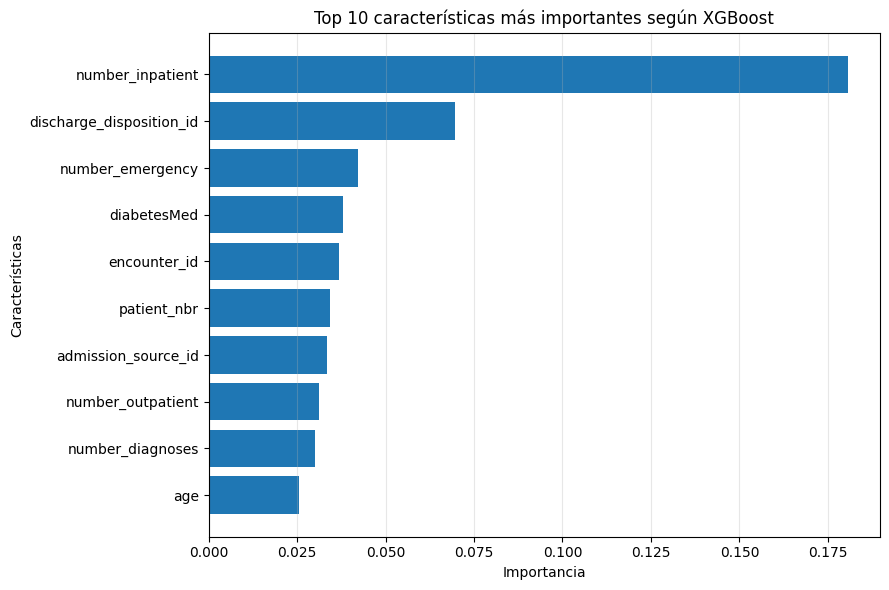

Figura guardada en: ..\visualizacion_gradient_boosting\xgboost_importancia_top10.png


In [11]:
# Visualización de las 10 características más importantes según XGBoost
carpeta_visualizaciones = Path("../visualizacion_gradient_boosting")
carpeta_visualizaciones.mkdir(exist_ok=True)

top_n = 10
top_features = df_importancia_xgb.head(top_n).copy()

plt.figure(figsize=(9, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importancia (XGBoost)"][::-1]
)

plt.xlabel("Importancia")
plt.ylabel("Características")
plt.title("Top 10 características más importantes según XGBoost")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

ruta_figura = carpeta_visualizaciones / "xgboost_importancia_top10.png"
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {ruta_figura}")

El análisis de importancia de características ayuda a interpretar el comportamiento del modelo. Las variables situadas en las primeras posiciones son las que más contribuyen al resultado de XGBoost según el criterio interno de importancia del modelo.

Esta información complementa la evaluación numérica, ya que permite observar qué variables del dataset tienen mayor influencia en la predicción de `readmitted`.

### 8- Evaluación final

Finalmente se comparan los modelos principales en una única tabla usando las métricas solicitadas y el resultado de validación cruzada.

Para AdaBoost se recontruye porque es muy largo y estos resultados son reales de la primera ejecución, no son inventados.

Para XGBoost no se hace porque tarda muchisimo menos y es mejor reejecutar.

In [17]:
# ============================================================
# RECUPERACIÓN DE RESULTADOS DE ADABOOST SI LA VARIABLE NO EXISTE
# ============================================================
# Esta celda evita tener que volver a ejecutar el GridSearchCV de AdaBoost porque tarda 3 horas con CPU
# Ya se ejecutó una vez, entoces guardamos el Top 10 y se muestra si no hay ya unos valores.

import pandas as pd

if "df_ada_grid" not in globals():

    print("df_ada_grid no estaba definida. Se reconstruye con los resultados ya obtenidos de AdaBoost.")

    datos_ada_recuperados = [
        {
            "Modelo": "Top 1",
            "n_estimators": 200,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 5,
            "CV F1 Macro": 0.413764,
            "CV Std": 0.005208,
            "Ranking": 1,
            "Test Accuracy": 0.5941,
            "Precision Macro": 0.5580,
            "Recall Macro": 0.4294,
            "F1-Score Macro": 0.4158
        },
        {
            "Modelo": "Top 2",
            "n_estimators": 200,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 2,
            "CV F1 Macro": 0.413741,
            "CV Std": 0.002447,
            "Ranking": 2,
            "Test Accuracy": 0.5927,
            "Precision Macro": 0.5410,
            "Recall Macro": 0.4272,
            "F1-Score Macro": 0.4120
        },
        {
            "Modelo": "Top 3",
            "n_estimators": 200,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 1,
            "CV F1 Macro": 0.413591,
            "CV Std": 0.002058,
            "Ranking": 3,
            "Test Accuracy": 0.5927,
            "Precision Macro": 0.5406,
            "Recall Macro": 0.4275,
            "F1-Score Macro": 0.4119
        },
        {
            "Modelo": "Top 4",
            "n_estimators": 200,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 10,
            "CV F1 Macro": 0.413529,
            "CV Std": 0.002119,
            "Ranking": 4,
            "Test Accuracy": 0.5936,
            "Precision Macro": 0.5496,
            "Recall Macro": 0.4279,
            "F1-Score Macro": 0.4119
        },
        {
            "Modelo": "Top 5",
            "n_estimators": 150,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 10,
            "CV F1 Macro": 0.413154,
            "CV Std": 0.002328,
            "Ranking": 5,
            "Test Accuracy": 0.5922,
            "Precision Macro": 0.5423,
            "Recall Macro": 0.4260,
            "F1-Score Macro": 0.4096
        },
        {
            "Modelo": "Top 6",
            "n_estimators": 150,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 1,
            "CV F1 Macro": 0.411949,
            "CV Std": 0.003991,
            "Ranking": 6,
            "Test Accuracy": 0.5926,
            "Precision Macro": 0.5342,
            "Recall Macro": 0.4263,
            "F1-Score Macro": 0.4098
        },
        {
            "Modelo": "Top 7",
            "n_estimators": 150,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 5,
            "CV F1 Macro": 0.411903,
            "CV Std": 0.005085,
            "Ranking": 7,
            "Test Accuracy": 0.5926,
            "Precision Macro": 0.5568,
            "Recall Macro": 0.4271,
            "F1-Score Macro": 0.4123
        },
        {
            "Modelo": "Top 8",
            "n_estimators": 150,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 2,
            "CV F1 Macro": 0.411779,
            "CV Std": 0.004776,
            "Ranking": 8,
            "Test Accuracy": 0.5927,
            "Precision Macro": 0.5448,
            "Recall Macro": 0.4272,
            "F1-Score Macro": 0.4121
        },
        {
            "Modelo": "Top 9",
            "n_estimators": 100,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 10,
            "CV F1 Macro": 0.411717,
            "CV Std": 0.002306,
            "Ranking": 9,
            "Test Accuracy": 0.5929,
            "Precision Macro": 0.5586,
            "Recall Macro": 0.4268,
            "F1-Score Macro": 0.4106
        },
        {
            "Modelo": "Top 10",
            "n_estimators": 100,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 1,
            "CV F1 Macro": 0.410809,
            "CV Std": 0.003881,
            "Ranking": 10,
            "Test Accuracy": 0.5918,
            "Precision Macro": 0.5432,
            "Recall Macro": 0.4247,
            "F1-Score Macro": 0.4077
        },
        {
            "Modelo": "Mejor AdaBoost",
            "n_estimators": 200,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 5,
            "CV F1 Macro": 0.413800,
            "CV Std": 0.005200,
            "Ranking": 1,
            "Test Accuracy": 0.5941,
            "Precision Macro": 0.5580,
            "Recall Macro": 0.4294,
            "F1-Score Macro": 0.4158
        }
    ]

    df_ada_grid = pd.DataFrame(datos_ada_recuperados).set_index("Modelo")

else:
    print("df_ada_grid ya existe en memoria. No se reconstruye.")

# Compatibilidad con posibles nombres de columnas usados en la tabla final
if "Precision" not in df_ada_grid.columns and "Precision Macro" in df_ada_grid.columns:
    df_ada_grid["Precision"] = df_ada_grid["Precision Macro"]

if "Recall" not in df_ada_grid.columns and "Recall Macro" in df_ada_grid.columns:
    df_ada_grid["Recall"] = df_ada_grid["Recall Macro"]

if "F1 Score" not in df_ada_grid.columns and "F1-Score Macro" in df_ada_grid.columns:
    df_ada_grid["F1 Score"] = df_ada_grid["F1-Score Macro"]

# Compatibilidad por si en alguna celda se escribió "Adaboost" con b minúscula
if "Mejor AdaBoost" not in df_ada_grid.index and "Mejor Adaboost" in df_ada_grid.index:
    df_ada_grid.loc["Mejor AdaBoost"] = df_ada_grid.loc["Mejor Adaboost"]

df_ada_grid

df_ada_grid ya existe en memoria. No se reconstruye.


,n_estimators,learning_rate,estimator__max_depth,estimator__min_samples_leaf,CV F1 Macro,CV Std,Ranking,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro,Precision,Recall,F1 Score
Modelo,,,,,,,,,,,,,,
Top 1,200,0.5,4,5,0.413764,0.005208,1,0.5941,0.5580,0.4294,0.4158,0.5580,0.4294,0.4158
Top 2,200,0.5,4,2,0.413741,0.002447,2,0.5927,0.5410,0.4272,0.4120,0.5410,0.4272,0.4120
Top 3,200,0.5,4,1,0.413591,0.002058,3,0.5927,0.5406,0.4275,0.4119,0.5406,0.4275,0.4119
Top 4,200,0.5,4,10,0.413529,0.002119,4,0.5936,0.5496,0.4279,0.4119,0.5496,0.4279,0.4119
Top 5,150,0.5,4,10,0.413154,0.002328,5,0.5922,0.5423,0.4260,0.4096,0.5423,0.4260,0.4096
Top 6,150,0.5,4,1,0.411949,0.003991,6,0.5926,0.5342,0.4263,0.4098,0.5342,0.4263,0.4098
Top 7,150,0.5,4,5,0.411903,0.005085,7,0.5926,0.5568,0.4271,0.4123,0.5568,0.4271,0.4123
Top 8,150,0.5,4,2,0.411779,0.004776,8,0.5927,0.5448,0.4272,0.4121,0.5448,0.4272,0.4121
Top 9,100,0.5,4,10,0.411717,0.002306,9,0.5929,0.5586,0.4268,0.4106,0.5586,0.4268,0.4106


In [18]:
# Identificación automática del mejor modelo según F1-Score Macro y Accuracy

import pandas as pd
from IPython.display import display

# Columnas finales que se van a comparar
columnas_deseadas = ["Test Accuracy", "Precision Macro", "Recall Macro", "F1-Score Macro"]

# Montaje directo de la tabla final con los resultados ya calculados
df_final = pd.concat([
    df_ada_base[columnas_deseadas],
    df_ada_grid.loc[["Mejor AdaBoost"], columnas_deseadas],
    df_gb_complementario[columnas_deseadas],
    df_xgb_base[columnas_deseadas],
    df_xgb_grid.loc[["Mejor XGBoost"], columnas_deseadas]
])

display(df_final)

# Conversión a numérico para comparar correctamente
df_final_numerico = df_final.copy()

for columna in columnas_deseadas:
    df_final_numerico[columna] = pd.to_numeric(df_final_numerico[columna], errors="coerce")

# Selección automática del mejor modelo
mejor_modelo_f1 = df_final_numerico["F1-Score Macro"].idxmax()
mejor_modelo_accuracy = df_final_numerico["Test Accuracy"].idxmax()

resumen_final = pd.DataFrame([
    {
        "Criterio": "Mejor modelo por F1-Score Macro",
        "Modelo seleccionado": mejor_modelo_f1,
        "Valor": round(df_final_numerico.loc[mejor_modelo_f1, "F1-Score Macro"], 4)
    },
    {
        "Criterio": "Mejor modelo por Accuracy",
        "Modelo seleccionado": mejor_modelo_accuracy,
        "Valor": round(df_final_numerico.loc[mejor_modelo_accuracy, "Test Accuracy"], 4)
    }
])

display(resumen_final)

,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro
AdaBoost Base,0.5599,0.3502,0.3720,0.3287
Mejor AdaBoost,0.5941,0.5580,0.4294,0.4158
Gradient Boosting Complementario,0.6010,0.5629,0.4306,0.4142
XGBoost Base,0.5972,0.5754,0.4240,0.4045
Mejor XGBoost,0.6088,0.5467,0.4485,0.4392


,Criterio,Modelo seleccionado,Valor
0,Mejor modelo por F1-Score Macro,Mejor XGBoost,0.4392
1,Mejor modelo por Accuracy,Mejor XGBoost,0.6088


La tabla final permite comparar de forma directa el rendimiento de **AdaBoost**, **Gradient Boosting complementario** y **XGBoost** sobre el mismo conjunto de datos.

Para este problema, el criterio más equilibrado es el **F1 macro**, ya que combina `Precision` y `Recall` y evita que la evaluación dependa únicamente de la clase mayoritaria. Por este motivo, el modelo seleccionado automáticamente por `F1-Score Macro` se considera la alternativa más equilibrada dentro de los modelos evaluados.